# Bài tập về nhà

## Mục tiêu 
- Tự viết lại code cho giải thuật K-means
- Hiểu sâu hơn giải thuật K-means qua việc tự viết lại code
- Ứng dụng mô hình tự viết vào các bài toán đã ra trên lớp

## Dữ liệu 

Giống dữ liệu của bài thực hành trên lớp (dữ liệu sinh ngẫu nhiên bằng sklearn và ảnh bird_small.png)

## Yêu cầu

Code K-means tự viết cho kết quả tương đương (không cần giống hệt) với giải thuật của thư viện sklearn khi áp dụng cho dữ liệu sinh ngẫu nhiên và dữ liệu ảnh.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
from skimage import io
from sklearn.cluster import KMeans
import warnings
import matplotlib.image as image
from IPython.core.display import Image, display
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
%cd D:/du_lieu_huan_luyen

# Giải thuật K-mean cho tệp dữ liệu sinh ngẫu nhiên

In [3]:
n_sample = 100
n_cluster = 3
centers = np.array([[1,1], [1,0], [0,1]])
X, y = make_blobs(n_samples= n_sample, random_state= 42,centers=centers, cluster_std=0.6) 
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:6])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 0.28394257  0.95630265]
 [ 0.49646949  0.81447257]
 [-0.15126273 -0.01590833]
 [ 0.71249546  0.88860461]
 [-0.584809    1.47225076]
 [ 1.49352695  0.26749381]]


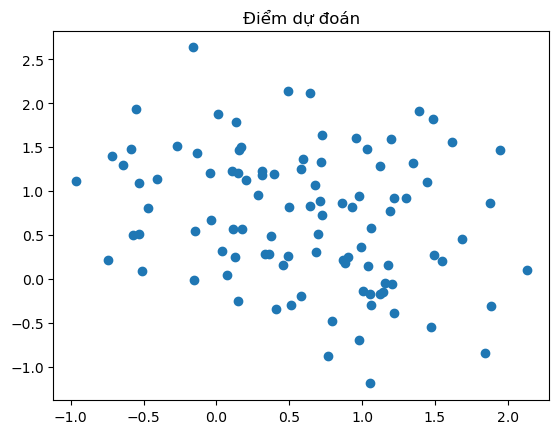

In [4]:
plt.figure()
plt.scatter(x= X[:,0], y = X[:,1])
plt.title('Điểm dự đoán')
plt.show()

# Tự xây dựng giải thuật K-means:

In [5]:
def k_mean_centers_init(X, n_cluster):
    data_index = np.random.choice(X.shape[0] , size= n_cluster)
    data = [X[i] for i in data_index]
    return data
def k_mean_assign_label(cluster, labels): #hàm giúp phân nhãn khi biết cụm
    distance = cdist(labels,cluster,metric='euclidean')
    return np.argmin(distance, axis=1)
def k_mean_update_centroid(X, labels,K):#giúp cập nhật tâm cụm khi biết nhãn
    new_centroids = np.zeros((K,X.shape[1]))
    for i in range(K):
        X_i = X[labels == i, :]
        if len(X_i) > 0:
            new_centroids[i] = np.mean(X_i, axis=0)
        else:
            pass
    return new_centroids
def has_converge(new_centroids, old_centroids):
    return np.allclose(new_centroids, old_centroids, atol=1e-4)

In [6]:
def k_means(X, n_cluster):
    current_cluster = k_mean_centers_init(X= X, n_cluster= n_cluster)
    while True:
        #Phân cụm dữ liệu vào điểm gần nhất
        labels = k_mean_assign_label(cluster=current_cluster, labels= X)
        #Cập nhật lại tâm cụm
        new_centroids = k_mean_update_centroid(X, labels=labels, K = n_cluster)
        #Kiểm tra hội tụ
        if has_converge(new_centroids, current_cluster):
            break
        current_cluster = new_centroids
    return current_cluster
    

In [7]:
def k_means_preDict(clusters, X):
    a = k_mean_assign_label(cluster=clusters, labels= X) 
    return a   


# Kiểm tra giải thuật K-means tự viết cho dữ liệu sinh ngẫu nhiên

In [8]:
k_mean_model_1 = k_means(X,n_cluster=n_cluster)
y_pred = k_means_preDict(k_mean_model_1,X)

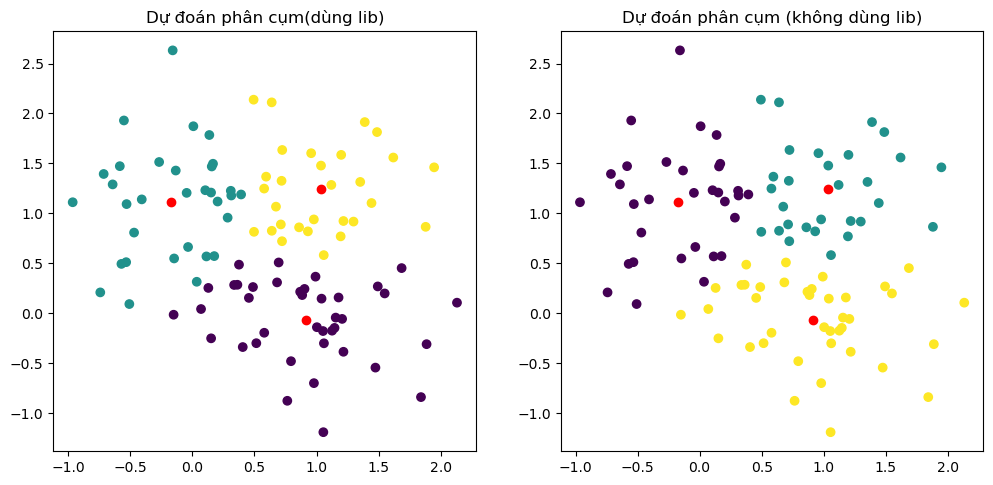

In [9]:
k_mean_model_2 = KMeans(n_clusters=n_cluster, random_state= 42)
k_mean_model_2.fit(X=X)
y_pred_lib = k_mean_model_2.predict(X=X)
#So sánh độ giống nhau giữa 2 mô hình viết bằng thư viện và viết bằng tay
plt.figure(figsize=(12,12))
plt.subplot(221)
plt.scatter(x = X[:,0], y = X[:, 1], c = y_pred_lib)
plt.scatter(x = k_mean_model_1[:,0], y = k_mean_model_1[:,1], c = 'red')
plt.title('Dự đoán phân cụm(dùng lib)')
plt.subplot(222)
plt.scatter(x = X[:,0], y = X[:, 1], c = y_pred)
plt.scatter(x = k_mean_model_2.cluster_centers_[:,0], y = k_mean_model_2.cluster_centers_[:,1], c = 'red')
plt.title('Dự đoán phân cụm (không dùng lib)')
plt.show()

# Ứng dụng K-means tự viết vào nén ảnh 

In [ ]:
path_img = 'bird_small.png'
img = io.imread(fname= path_img)
data_img = (img / 255.0).reshape(-1,img.shape[2])


## Nén ảnh bằng giải thuật K-means tự viết

- Tạo file nén ảnh bằng giải thuật K-means tự viết
- Hiển thị kết quả của giải thuật tự viết và giải thuật của sklearn để so sánh


In [ ]:
#Nén ảnh với color = 10 bằng hàm tự viết 

n_color = 10
clusters = k_means(data_img ,n_cluster= n_color)
labels = k_means_preDict(clusters = clusters, X = data_img)
img_1 = clusters[labels]
img_1 = np.reshape(img_1,img.shape)
image.imsave('img_1.png', img_1)

In [42]:
#Nén ảnh với color = 10 bằng thư viện

n_color = 10
k_means_model = KMeans(n_clusters = n_color, random_state = 42)
k_means_model.fit(data_img)
centroids = k_means_model.cluster_centers_
img_2 = centroids[k_means_model.labels_]
img_2 = np.reshape(img_2,img.shape)
image.imsave('img_2.png',img_2)

Ảnh nén bằng K-means tự viết


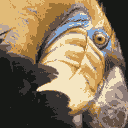

Ảnh nén bằng K_means của thư viện


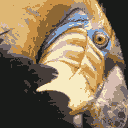

Ảnh gốc


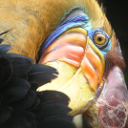

In [ ]:
print('Ảnh nén bằng K-means tự viết')
display(Image(data='img_1.png',width=250,unconfined=True))
print('Ảnh nén bằng K_means của thư viện')
display(Image(data='img_2.png',width=250,unconfined=True))
print('Ảnh gốc')
display(Image(data= 'bird_small.png',width =250,unconfined = True))